# Subscription Utilization Analysis

Compare fixed subscription package sizes (6/12/18/24 concerts) with actual events recorded per account and season to surface under-utilization patterns.


In [7]:
!pip install jinja2

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_style("whitegrid")
BASE_DIR = Path.cwd()
ACCOUNT_YEAR_PATH = BASE_DIR / "subscription_utilization_account_year.csv"
ACCOUNT_PATH = BASE_DIR / "subscription_utilization_accounts.csv"

account_year_df = pd.read_csv(ACCOUNT_YEAR_PATH)
account_df = pd.read_csv(ACCOUNT_PATH)

account_year_df.head()


,acct_id,fiscal_year,price_code_type,package_size,actual_events,tickets_sold,avg_seats_per_event,expected_events,event_gap,utilization_pct
0,100103,FY23,Fixed Established Subscription 6 Concert,6.0,6,6,1.0,6.0,0.0,1.0
1,100103,FY24,Fixed Established Subscription 6 Concert,6.0,6,6,1.0,6.0,0.0,1.0
2,100521,FY23,Fixed Established Subscription Sunday,4.0,4,4,1.0,4.0,0.0,1.0
3,100521,FY24,Fixed Established Subscription Sunday,4.0,4,4,1.0,4.0,0.0,1.0
4,100532,FY23,Fixed Sophomore Subscription 6 Concert,6.0,6,12,1.2,6.0,0.0,1.0


## Summary Statistics


In [9]:
summary_cols = [
    "subscription_expected_events",
    "subscription_actual_events",
    "subscription_event_gap",
    "subscription_utilization_pct",
    "subscription_packages",
]

display(account_df[summary_cols].describe())

utilization_rate = account_df["subscription_utilization_pct"].dropna()
print(
    f"Accounts analyzed: {len(utilization_rate):,} | Median utilization: {utilization_rate.median():.2f}"
)
print(
    f"Share below 80% utilization: {(utilization_rate < 0.8).mean():.1%}"
)


,subscription_expected_events,subscription_actual_events,subscription_event_gap,subscription_utilization_pct,subscription_packages
count,2332.000000,2332.000000,2332.000000,2332.000000,2332.000000
mean,11.566895,10.075472,1.491424,0.926569,1.222556
std,9.981333,8.105554,5.291698,0.301609,0.489921
min,4.000000,1.000000,-36.000000,0.041667,1.000000
25%,6.000000,6.000000,0.000000,0.916667,1.000000
50%,8.000000,8.000000,0.000000,1.000000,1.000000
75%,12.000000,12.000000,1.000000,1.000000,1.000000
max,90.000000,52.000000,62.000000,4.000000,4.000000


Accounts analyzed: 2,332 | Median utilization: 1.00
Share below 80% utilization: 17.0%


## Visualizations


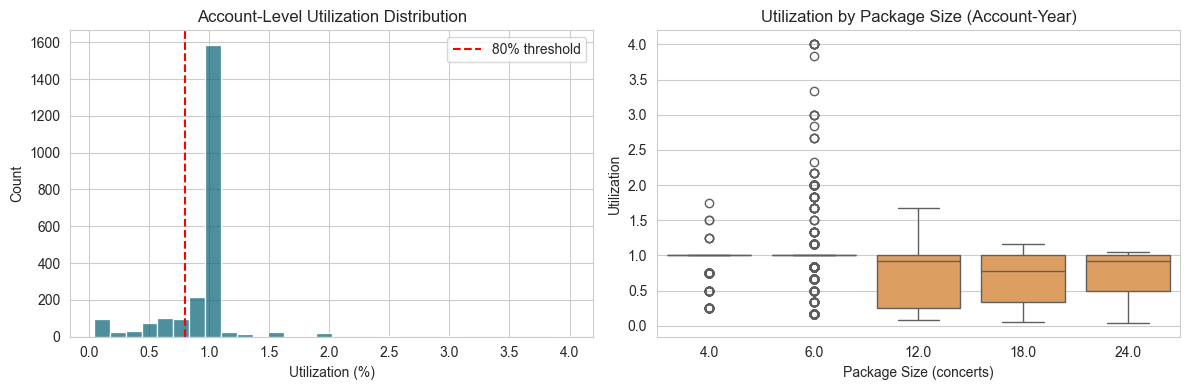

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(account_df["subscription_utilization_pct"], bins=30, ax=axes[0], color="#116A7B")
axes[0].set_title("Account-Level Utilization Distribution")
axes[0].set_xlabel("Utilization (%)")
axes[0].axvline(0.8, color="red", linestyle="--", label="80% threshold")
axes[0].legend()

sns.boxplot(
    data=account_year_df,
    x="package_size",
    y="utilization_pct",
    ax=axes[1],
    color="#F29E4C",
)
axes[1].set_title("Utilization by Package Size (Account-Year)")
axes[1].set_xlabel("Package Size (concerts)")
axes[1].set_ylabel("Utilization")

plt.tight_layout()
plt.show()


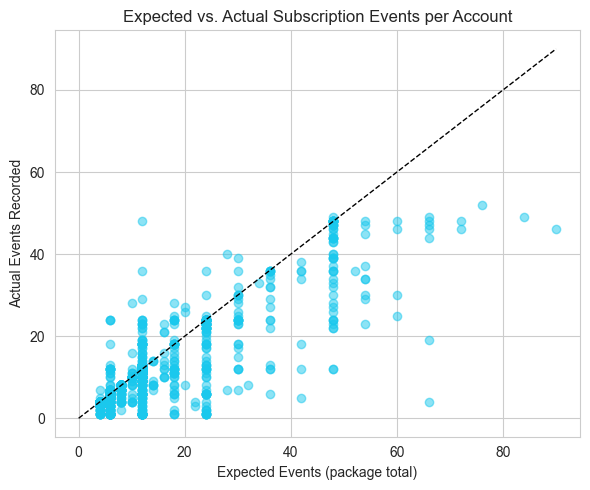

In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(
    account_df["subscription_expected_events"],
    account_df["subscription_actual_events"],
    alpha=0.5,
    color="#1AC8ED",
)
plt.plot([0, account_df["subscription_expected_events"].max()],
         [0, account_df["subscription_expected_events"].max()], 'k--', linewidth=1)
plt.title("Expected vs. Actual Subscription Events per Account")
plt.xlabel("Expected Events (package total)")
plt.ylabel("Actual Events Recorded")
plt.tight_layout()
plt.show()


## Under-Utilized Accounts


In [12]:
under_utilized = account_df[account_df["subscription_utilization_pct"] < 0.8]
summary = (
    under_utilized.sort_values("subscription_utilization_pct")
    .head(10)
    .loc[:, [
        "acct_id",
        "subscription_expected_events",
        "subscription_actual_events",
        "subscription_event_gap",
        "subscription_utilization_pct",
    ]]
)
summary.style.format({
    "subscription_utilization_pct": "{:.2f}",
})


,acct_id,subscription_expected_events,subscription_actual_events,subscription_event_gap,subscription_utilization_pct
2271,9363705,24.000000,1,23.000000,0.04
1618,7645753,24.000000,1,23.000000,0.04
1723,7793301,24.000000,1,23.000000,0.04
598,368470,24.000000,1,23.000000,0.04
2211,9194084,24.000000,1,23.000000,0.04
1967,8666573,24.000000,1,23.000000,0.04
798,2415150,24.000000,1,23.000000,0.04
15,106087,24.000000,1,23.000000,0.04
246,211423,18.000000,1,17.000000,0.06
1761,8093856,18.000000,1,17.000000,0.06
